In [212]:
#Si estas en colab, corre esta celda para instalar las librerias
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer

# Sesión 6 Laboratorio de Computación Cuántica 2

## Ruido cuántico

Cuando nosotros trabajamos con modelos ideales y simulaciones de cómputo cuántico, por lo general, los sistemas se comportan de formas ideales, sin problemas ni conflictos. Ya sabemos que los estados cuánticos se codifican con un ket $|\psi\rangle$ y su evolución se da con ayuda de operadores unitarios $\hat{U}$ si es que las cosas son bonitas

Pero la realidad jamas es bonita.


La era actual del cómputo cuántico se le conoce como la era NISQ, en donde todas las computadoras cuánticas tienen ruido. Esto es debido a que las computadoras cuánticas se ven afectadas por el entorno en el cual estas viven.


Para modelar estos errores, existe un formalismo completo dentro del cómputo cuántico que permite que nosotros estudiemos esta parte con calma: El Formalismo de las Matrices de Densidad

### Matrices de Densidad: Estados Puros y Mixtos

Cuando nosotros trabajamos en computo cuántico de manera ideal, cada estado se representa con un ket $|\psi\rangle$, el cual se visualiza como un elemento del espacio de Hilbert $H$ el cual representa el estado cuántico de los qubits. 


Sin embargo, esto solo ocurre si estamos trabajando con un sistema completamente aislado. En la realidad, podemos tener 2 escenarios que nos generen problemas: 


1.- Si nuestro sistema esta en entrelazamiento con el entorno, lo cual lo hace una parte de un sistema aun mas grande el cual es mas complicado. 


2.- Si nuestro sistema esta sujeto a errores físicos clásicos que hace que no podamos decidir con exactitud si es un estado u otro.

Para ello, se crea una nueva entidad matemática que se le conoce como la Matriz de Densidad $\rho$, que es un objeto matemático que similar al ket que describe toda la información del sistema. Sea $\{|\psi_i\rangle\}_{i\in \N}$ un conjunto de estados posibles sobre los cuales cada estado tiene una probabilidad $p_i$ de aparecer, la matriz de densidad del sistema se define como $\rho=\sum_i p_i|\psi_i\rangle\langle\psi_i|$


La matriz de densidad siempre tiene que cumplir las siguientes propiedades:

>1.- Es Hermitica: $\rho^\dagger=\rho$

>2.- Tiene traza 1: $tr(\rho)=1$

>3.- Es positiva definida: $\langle\psi|\rho|\psi\rangle> 0$ $\forall |\psi\rangle$



La Matriz de Densidad puede ser

>1.- Pura $\rho=|\psi\rangle\langle\psi|$ de modo que $tr(\rho^2)=1$. Una matriz de densidad pura representa un estado físico claro

>2.- Mixta $\rho=\sum_i p_i|\psi_i\rangle\langle\psi_i|$ de modo que $tr(\rho^2)<1$. Una matriz de densidad mixta representa un estado físico difuso

$|\psi\rangle \rightarrow U|\psi'\rangle$

La evolución unitaria sobre una matriz de densidad se visualiza con $\rho\Rightarrow U\rho U^\dagger$ (Actividad de Tarea 1: ¿Por que?)

#### Representación en la esfera de Bloch

Toda matriz de densidad de un sistema de 1 Qubit se puede representar en la esfera de Bloch con la siguiente fórmula:

$$\rho=\frac{1}{2}(I+\vec{r}\cdot \vec{\sigma})$$

donde $\vec{r} = (x,y,z)$ es el vector de Bloch y $\vec{\sigma}=(\hat{X},\hat{Y},\hat{Z})$ son las matrices de Pauli.


(Actividad de Tarea 2: Demostrar que $\vec{r}$ es unitario si y solo si $\rho$ es un estado puro)

### Traza Parcial



$\ket{\psi}=\frac{\ket{00}+\ket{11}}{\sqrt{2}}$  

$\rho=\ket{\psi}\bra{\psi}=\frac{\ket{00}+\ket{11}}{\sqrt{2}}\frac{\bra{00}+\bra{11}}{\sqrt{2}}$

Cuando trabajamos con sistemas cuánticos reales, casi nunca tenemos un sistema completamente aislado. En realidad, el sistema es una mezcla de Sistema util + Entorno y se puede representar el estado total como:

$$\rho_{SE}$$

Sin embargo, en la práctica, solo observamos el sistema, pues el entorno puede ser sumamente complicado.


Aquí es en donde entra la Traza Parcial. La Traza Parcial nos permite obtener el estado de un sistema compuesto, ignorando el otro sistema.

$$\rho_S=tr_E(\rho_{SE})$$

La traza parical "ignora" el sistema que trazamos, y nos deja unicamente con el sistema que podemos medir.

Con esto podemos hacer un modelo del ruido cuántico intuitivo (Aunque no completamente acertado). Imaginemos que $\rho_S$ representa el sistema cuántico a estudiar y $\rho_E$ representa el entorno que queremos eliminar (En realidad, casi nunca podemos representar el sistema y el entorno de manera separada, pues normalmente suelen estar entrelazados de forma no separable)

Entonces una evolución unitaria sobre el Sistema, es en realidad una evolución unitaria sobre TODO el conjunto de entorno + sistema, para despues trazar el entorno:


$$\rho_S\Rightarrow tr_E(U(\rho_S\otimes\rho_E)U^\dagger)$$

### Canales Cuánticos

Ya vimos que para evolucionar una matriz de densidad de forma unitario se aplica $\rho\rightarrow U\rho U^\dagger$. Vamos a generalizar esto para la evolucion de todo tipo de sistemas, incluso con ruido

Un canal cuántico es la forma más general de describir la evolución de un estado cuántico. Se representan por $\mathcal{E}(\rho)=\rho '$. Los Canales cuánticos cumplen unas condiciones muy claras llamdas condiciones CPTP (Completely Positive Trace Preservation)

1.- Preservan la traza: $tr(\mathcal{E}(\rho))=1$

2.- Son completamente positivos incluso bajo entrelazamiento: $(\mathcal{E}(\rho)\otimes\mathcal{I})(\rho_{SA})\geq 0$

Valor esperado de una matriz de densidad: $tr(\rho A)$


Estos canales tienen diversas representaciones. La mas sencilla y que veremos aquí, es la representación de Kraus

Todo canal cuántico que cumpla las propiedades anteriores se pueden escribir como:


$$\mathcal{E}(\rho)=\sum_i K_i \rho K_i^\dagger$$

en donde 

$$\sum_i K_i^\dagger K_i=I$$


### Modelos de ruido mas comunes

Cuando trabajamos con una computadora cuántica real, existen diversos modelos de ruido que se presentan de manera común. Vamos a ver los principales y que hacen en el sistema:

#### Bit-flip

$|0\rangle \iff |1\rangle$. Es un canal cuántico en el cual un qubit con cierta probabilidad cambia el estado en el que está por su estado opuesto. Se visualiza como:

$$
\mathcal{E}(\rho) = (1-p)\rho + p\, X \rho X
$$

y sus operadores de Kraus son

$$
K_0 = \sqrt{1-p}\, I,
\quad
K_1 = \sqrt{p}\, X
$$

#### Phase-flip

$|+\rangle \iff |-\rangle$. Aunque no cambia las probabilidades, si destruye la interferencia. Se visualiza como:

$$
\mathcal{E}(\rho) = (1-p)\rho + p\, Z \rho Z
$$

y sus operadoes de Kraus son 

$$
K_0 = \sqrt{1-p}\, I,
\quad
K_1 = \sqrt{p}\, Z
$$




#### Bit-Phase-flip

Es una combinación de los 2 canales anteriores, dado que $\hat{Y}=i\hat{X}\hat{Z}$ (Actividad de tarea 3: Demuestra que para las matrices de Paulli se cumple que $\hat{\sigma_j}\hat{\sigma_k}=\delta_jk\hat{I}+i\sum_{l=1}^3\varepsilon_{jkl}\hat{\sigma}_l$):

$$
\mathcal{E}(\rho) = (1-p)\rho + p\, Y \rho Y
$$

y sus operadoes de Kraus son 

$$
K_0 = \sqrt{1-p}\, I,
\quad
K_1 = \sqrt{p}\, Y
$$



#### Depolarizing Channel

Este canal cuántico tambien se le conoce como canal de despolarización. Si con una probabilidad p, la matriz de densidad del sistema se converte en el estado máximamente mixto $\frac{I}{2}$ (Actividad para Tarea 4: Demostrar que $\frac{I}{2}=\frac{\rho+X\rho X + Y\rho Y+ Z \rho Z}{4}$ y sustituir dicha expresión en $\mathcal{E}(\rho)=\frac{pI}{2}+(1-p)\rho$ para verificar la fórmula de abajo)


$$
\mathcal{E}(\rho) = (1-p)\rho + \frac{p}{3}\left( X \rho X + Y \rho Y + Z \rho Z \right)
$$

Y sus operadores de Kraus son:


$$
K_0 = \sqrt{1-p}\, I
$$

$$
K_1 = \sqrt{\frac{p}{3}}\, X,
\quad
K_2 = \sqrt{\frac{p}{3}}\, Y,
\quad
K_3 = \sqrt{\frac{p}{3}}\, Z
$$

#### Amplitude damping

Si usamos fotones para realizar modelos cuánticos, un foton que decae del estado $|1\rangle$ al estado $|0\rangle$ pierde energía. A esto se le llama amplitude damping. si ocurre con probabilidad $\gamma$, los operadores de Kraus asociados son:

$$
K_0 =
\begin{pmatrix}
1 & 0 \\
0 & \sqrt{1-\gamma}
\end{pmatrix},
\quad
K_1 =
\begin{pmatrix}
0 & \sqrt{\gamma} \\
0 & 0
\end{pmatrix}
$$



#### Phase Damping

Se alteran los valores de fase, mas no los valores de probabilidad de medición. Esto genera perdida de información del sistema, lo que puede alterar el funcionamiento de algoritmos

$$
K_0 =
\begin{pmatrix}
1 & 0 \\
0 & \sqrt{1-\lambda}
\end{pmatrix},
\quad
K_1 =
\begin{pmatrix}
0 & 0 \\
0 & \sqrt{\lambda}
\end{pmatrix}
$$

In [214]:
from qiskit_aer.noise import (
    pauli_error,
    depolarizing_error,
    amplitude_damping_error,
    phase_damping_error,
    NoiseModel
)

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit import transpile

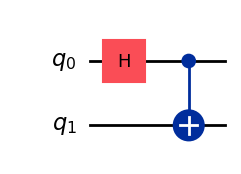

In [215]:
def bell_circuit():
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    return qc

qc = bell_circuit()
qc.draw('mpl')

Aquí veremos primero como usando Pauli_error podemos aplicar los primeros 3 canales cuánticos al sistema.

In [216]:
def bit_flip_error(p):
    return pauli_error([
        ('X', p),
        ('I', 1 - p)
    ])

def phase_flip_error(p):
    return pauli_error([
        ('Z', p),
        ('I', 1 - p)
    ])

def bit_phase_flip_error(p):
    return pauli_error([
        ('Y', p),
        ('I', 1 - p)
    ])

Ahora veamos como aplicarlos a un circuito cuántico de algún sistema. Aquí generaremos un circuito cuantico sencillo con una matriz Hadamard y usaremos NoiseModel para modelar el ruido de dicho circuito

In [237]:
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.h(0)
qc.measure(0, 0)

In [238]:
p = 0.2

noise_model = NoiseModel() #Creamos el modelo de ruido vacío

error = phase_flip_error(p) #Generamos un error de phase flip con probabilidad p

noise_model.add_all_qubit_quantum_error(error, ['h']) #Aplicamos este error a todas las puertas H del circuito

Esto ahora hace que toda compuerta hadamard que apliquemos en el sistema, sea una Hadamard imperfecta, con una probabilidad de p=0.2 de aplicar un bitflip al sistema, generando que siempre puesa aplicar un bitflip. Veamos como se visualiza este error con alguna simulación de los sistemas

In [239]:
backend = AerSimulator(noise_model=noise_model)

compiled = transpile(qc, backend, optimization_level=0)
result = backend.run(compiled, shots=1000).result()

counts = result.get_counts()
print(counts)

{'0': 796, '1': 204}


Veamos el depolarizing channel:

In [240]:
n=1 # numero de qubits
p = 0.2 # probabilidad de error

def depol_error(p,n):
    return depolarizing_error(p, n)  

In [245]:
from qiskit_aer.noise import NoiseModel

p = 0.2

noise_model = NoiseModel()
error = depol_error(p, 1)

noise_model.add_all_qubit_quantum_error(error, ['u1','u2','u3'])

In [246]:
qc = QuantumCircuit(1,1)
qc.x(0)
qc.measure(0,0)

In [249]:
backend = AerSimulator(noise_model=noise_model)

compiled = transpile(qc, backend, optimization_level=0)
result = backend.run(compiled, shots=1000).result()

counts = result.get_counts()
print(counts)

{'1': 892, '0': 108}


Veamos como se ve el error aplicado a un estado de bell

In [ ]:
def bell_circuit():
    qc = QuantumCircuit(2, 2)
    qc.h(0)
    qc.cx(0, 1)
    qc.measure([0,1], [0,1])   # medición simple
    return qc


def run_experiment(error_1q, error_2q, shots=2000):
    
    qc = bell_circuit()
    
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(error_1q, ['u1','u2','u3'])  # Ruido en compuertas de 1 qubit (Qiskit Aer tiene 3 tipos de compuertas de 1 qubit: u1, u2, u3)
    
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])  # Ruido en compuertas de 2 qubits (CNOT)
    
    backend = AerSimulator(noise_model=noise_model)
    
    compiled = transpile(qc, backend, optimization_level=0)
    result = backend.run(compiled, shots=shots).result()
    
    return result.get_counts()

In [250]:
p = 0.1

# Bit flip
counts_bit = run_experiment(
    bit_flip_error(p),
    bit_flip_error(p).tensor(bit_flip_error(p))
)

# Phase flip
counts_phase = run_experiment(
    phase_flip_error(p),
    phase_flip_error(p).tensor(phase_flip_error(p))
)

# Depolarizing
counts_depol = run_experiment(
    depol_error(p, 1),
    depol_error(p, 2)
)

print("Bit flip:", counts_bit)
print("Phase flip:", counts_phase)
print("Depolarizing:", counts_depol)

Bit flip: {'01': 202, '00': 800, '10': 184, '11': 814}
Phase flip: {'00': 981, '11': 1019}
Depolarizing: {'11': 948, '00': 961, '01': 48, '10': 43}


Ahora hagamos algo un poco mas complejo. Apliquemos Amplitude Dampling y Phase Dampling al algoritmo de Bernstein Vazirani que ya programamos

In [226]:
def amp_damp(p):
    return amplitude_damping_error(p)

def phase_damp(p):
    return phase_damping_error(p)

Usaremos el oráculo que ya tenemos para Bernstein-Vazirani

In [227]:
def bv_oracle(s, n):
    

    qc = QuantumCircuit(n+1)


    for i, bit in enumerate(s):
        if bit == '1':
            qc.cx(i, n)

    qc.barrier()

    return qc

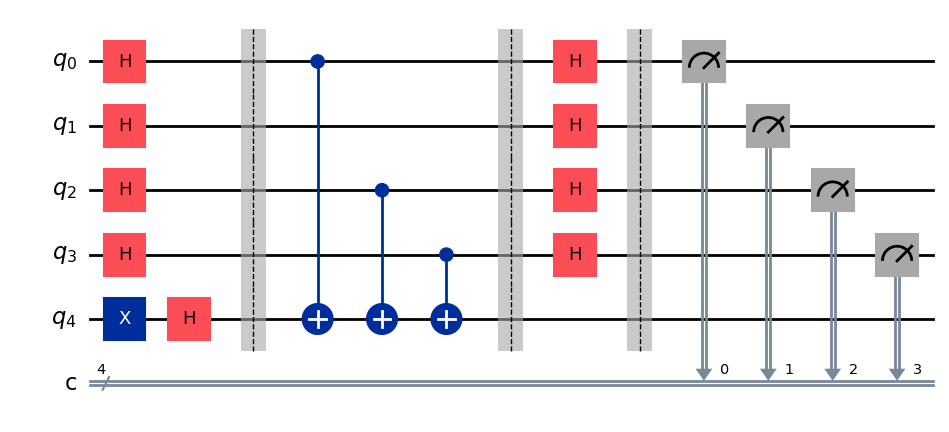

In [228]:
def bv_circuit(s, n):
    qc = QuantumCircuit(n+1, n)
    
    qc.x(n) # preparar ancilla en |1>
    
    qc.h(range(n+1)) # superposición

    qc.barrier()
    
    qc.compose(bv_oracle(s, n), inplace=True) # oráculo
    
    qc.h(range(n)) # Hadamard final

    qc.barrier()
    
    qc.measure(range(n), range(n)) # medir
    
    return qc

qc = bv_circuit("1011", 4)
qc.draw('mpl')

Verifiquemos B-V Sin ruido

In [251]:
def run_bv(s, n, shots=1000):
    qc = bv_circuit(s, n)
    
    backend = AerSimulator(method='statevector')
    
    compiled = transpile(qc, backend, optimization_level=0)
    result = backend.run(compiled, shots=shots).result()
    
    return result.get_counts()


# Parámetros
n = 4
s = "1011"

counts = run_bv(s, n)

print("Resultado:", counts)  #Recuerda que qiskit devuelve los bits en orden invertido, así que el resultado esperado es '1101'

Resultado: {'1101': 1000}


Ahora que ya verificamos que B-V funciona correctamente, vamos a implementar modelos de error:

In [230]:
def build_noise_model(error_1q):
    noise_model = NoiseModel()
    
    # Ruido en compuertas de 1 qubit
    noise_model.add_all_qubit_quantum_error(
        error_1q,
        ['u1','u2','u3']
    )
    
    # Ruido en compuertas de 2 qubits (CX)
    noise_model.add_all_qubit_quantum_error(
        error_1q.tensor(error_1q),
        ['cx']
    )
    
    return noise_model

In [252]:
from qiskit_aer import AerSimulator

def run_bv(s, n, noise_model=None, shots=2000):  #Generamos una función que ejecute el algoritmo de Bernstein-Vazirani con un modelo de ruido opcional
    
    qc = bv_circuit(s, n)
    
    backend = AerSimulator(noise_model=noise_model)
    
    compiled = transpile(qc, backend, optimization_level=0)
    result = backend.run(compiled, shots=shots).result()
    
    return result.get_counts()

In [253]:
n = 4
s = "1011"
p = 0.2

noise_amp = build_noise_model(amp_damp(p))
noise_phase = build_noise_model(phase_damp(p))


counts_ideal = run_bv(s, n)
counts_amp = run_bv(s, n, noise_amp) #Ejecutamos el algoritmo con ruido de amplitude dampling
counts_phase = run_bv(s, n, noise_phase)  #Ejecutamos el algoritmo con ruido de phase damping

print("Ideal:", counts_ideal)
print("Amplitude damping:", counts_amp)
print("Phase damping:", counts_phase)

Ideal: {'1101': 2000}
Amplitude damping: {'1011': 6, '0001': 181, '1001': 194, '0100': 122, '1101': 473, '1000': 107, '0000': 391, '0101': 248, '1111': 22, '1100': 212, '0111': 13, '0011': 4, '0010': 14, '1010': 5, '1110': 6, '0110': 2}
Phase damping: {'1101': 1242, '0001': 88, '1001': 131, '1110': 7, '0101': 183, '0000': 85, '1000': 21, '1100': 126, '0011': 2, '1111': 56, '0100': 37, '1010': 3, '0111': 4, '0010': 4, '1011': 9, '0110': 2}


Para aplicar tus propios operadores de Kraus:

In [233]:
import numpy as np
from qiskit.quantum_info import Kraus

def kraus_amp_damp(p):
    K0 = np.array([[1, 0],
                   [0, np.sqrt(1 - p)]])
    
    K1 = np.array([[0, np.sqrt(p)],
                   [0, 0]])
    
    return Kraus([K0, K1])

In [235]:
from qiskit_aer.noise import NoiseModel

def build_kraus_noise(kraus_channel):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(
        kraus_channel,
        ['u1','u2','u3']
    )
    
    return noise_model